In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [2]:
fname = "segm_results_pedestrains_e12_full.npz"

In [3]:
file = np.load(fname, allow_pickle = True)

In [4]:
for f in file:
    print(f)

y
p
log


In [5]:
#y = file["y"]
p = file["p"]

In [6]:
idx = 120

In [7]:
heatmap1 = plt.imshow(y[0, idx], cmap="hot_r") #, cmap='hot', interpolation='nearest')'
plt.colorbar(heatmap1)

NameError: name 'y' is not defined

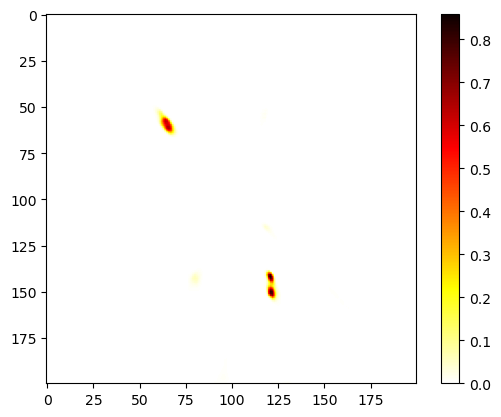

In [8]:
heatmap1 = plt.imshow(p[0, idx], cmap="hot_r") #, cmap='hot', interpolation='nearest')'
plt.colorbar(heatmap1)

## Autocorrelation

In [36]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import libpysal
from esda.moran import Moran
from libpysal.weights import lat2W
import numpy as np
import matplotlib.pyplot as plt
from esda.moran import Moran
from libpysal.weights import DistanceBand
import libpysal
from libpysal.weights import W

In [32]:
# Function to create a DistanceBand with rounded distances
def get_new_distance_band(coords, w, w_last):
    n = coords.shape[0]
    weights = {}
    for i in range(n):
        weights[i] = list(np.setdiff1d(w.neighbors[i], w_last.neighbors[i]))
    return W(weights)

In [37]:
max_distance = 20
step = 2
data = p[0, idx]

nrows, ncols = data.shape
x, y = np.meshgrid(np.arange(ncols), np.arange(nrows))
coords = np.dstack([x, y]).reshape(-1, 2)
data_flat = data.flatten()

distances = []
morans_i_values = []

for distance in range(step, max_distance + 1, step):
    
    print("Dist:", distance)

    if distance != step:
        print("new part")
        w = DistanceBand(coords, threshold=distance+0.5, binary=True, silence_warnings=False)
        w_new = get_new_distance_band(coords, w, w_last)
    else:
        w = DistanceBand(coords, threshold=distance+0.5, binary=True, silence_warnings=False)
        w_new = w
    moran = Moran(data_flat, w_new)
    distances.append(distance//step)
    morans_i_values.append(moran.I)

    print("correlation:", moran.I)

    w_last = w

Dist: 2
correlation: 0.7050669171367026
Dist: 4
new part
correlation: 0.3054006229483999
Dist: 6
new part
correlation: 0.12715053278742114
Dist: 8
new part
correlation: 0.07109298458516315
Dist: 10
new part
correlation: 0.036734502824218106
Dist: 12
new part
correlation: 0.0128739847765154
Dist: 14
new part
correlation: 0.0007231505121721079
Dist: 16
new part
correlation: -0.0021647923079951763
Dist: 18
new part
correlation: -0.002662873860036318
Dist: 20
new part
correlation: -0.002743344907003958


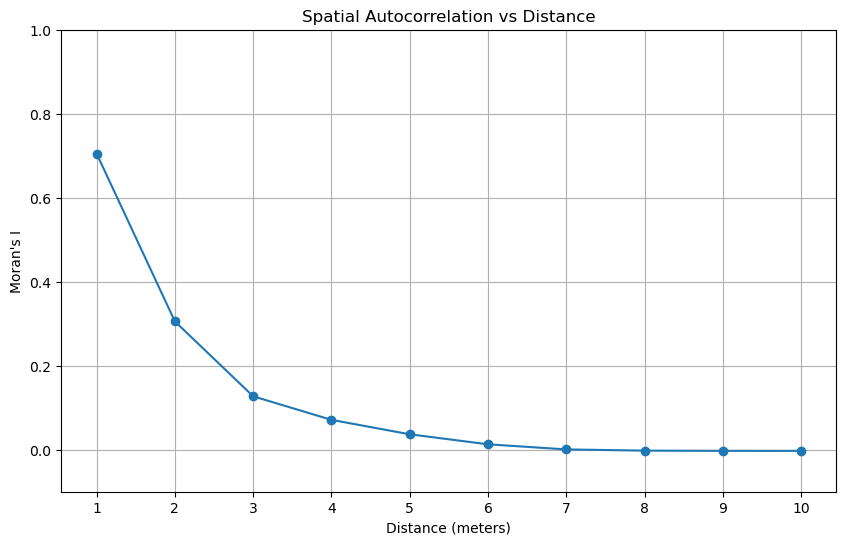

In [39]:
plt.figure(figsize=(10, 6))
plt.plot(distances, morans_i_values, marker='o', linestyle='-')
plt.title('Spatial Autocorrelation vs Distance')
plt.xlabel('Distance (meters)')
plt.ylabel('Moran\'s I')
plt.ylim([-0.1,1])
#plt.xlim([0,20])
plt.xticks([1,2,3,4,5,6,7,8,9,10])
plt.grid(True)
#plt.show()
plt.savefig("autocor_distance_v2.pdf", dpi=300, bbox_inches = "tight")

In [125]:
from libpysal.weights import W

# Example 200x200 pixel data (replace this with your segmentation data)
data = np.random.random((200, 200))

# Function to create a DistanceBand with rounded distances
def create_rounded_distance_band(coords, threshold):
    w = DistanceBand(coords, threshold=threshold+1, binary=True, silence_warnings=False)
    n = coords.shape[0]
    weights = {}
    for i in range(n):
        weights[i] = []
        for j in  w.neighbors[i]:
            distance = np.linalg.norm(coords[i] - coords[j])
            rounded_distance = round(distance)
            if rounded_distance <= threshold:
                weights[i].append(j)
    return W(weights)

# Function to calculate Moran's I for different distances
def calculate_morans_i(data, max_distance,step = 1):
    nrows, ncols = data.shape
    x, y = np.meshgrid(np.arange(ncols), np.arange(nrows))
    coords = np.dstack([x, y]).reshape(-1, 2)
    data_flat = data.flatten()
    
    distances = []
    morans_i_values = []
    
    for distance in range(2, max_distance + 1, step):
        print("dist:", distance)
        w = create_rounded_distance_band(coords, threshold=distance)
        print("w calculated")
        moran = Moran(data_flat, w)
        distances.append(distance//step)
        morans_i_values.append(moran.I)
        print(moran.I)
    
    return distances, morans_i_values